In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Imports and GPU check
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import json
import pathlib
import warnings
import contextlib

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import tifffile
import liffile
import napari
from napari.utils.colormaps import DirectLabelColormap

from scipy.ndimage import distance_transform_edt
from scipy import stats as scipy_stats

from skimage.filters import (
    gaussian, median as median_filter,
    threshold_li, threshold_mean, threshold_triangle, threshold_yen,
)
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import (
    closing, disk, square, erosion,
    remove_small_holes, expand_labels,
)
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

import joblib
from joblib import Parallel, delayed
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── GPU availability ──────────────────────────────────────────────────────────
GPU_AVAILABLE = False
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
except ImportError:
    pass
print(f"GPU available: {GPU_AVAILABLE}")


@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib so it updates a tqdm progress bar."""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Constants and functions
# ══════════════════════════════════════════════════════════════════════════════

# ── Label channel convention ──────────────────────────────────────────────────
# Combined TIF layout: (9, Y, X) float32
#   Channels 0–3: raw projection  (B cells, Vasculature, Brightfield, CART)
#   Channel  4: chip        (1 = on-chip region)
#   Channel  5: vasculature (1 = vasculature)
#   Channel  6: b_cells     (1 = B cell)
#   Channel  7: cart_cells  (1 = CART cell)
#   Channel  8: tumour      (1 = tumour)
NUM_RAW_CHANNELS = 4
LABEL_NAMES = ["chip", "vasculature", "b_cells", "cart_cells", "tumour"]

GAUSS_SIGMAS_UM = [5, 10, 20, 50, 100]
PROXIMITY_RADII_UM = [5, 10, 20, 30, 40, 50, 100]

REGIONS = ["chip", "not_chip", "tumour", "chip_not_tumour",
           "chip_vasculature", "chip_not_vasculature", "left", "right"]

RAW_CHANNEL_NAMES = ["B cells (raw)", "Vasculature (raw)", "Brightfield", "CART (raw)"]

EDITABLE_LABELS = ["chip", "tumour"]

LABEL_COLORMAPS = {
    "chip":        DirectLabelColormap(color_dict={0: "transparent", 1: "cyan"}),
    "vasculature": DirectLabelColormap(color_dict={0: "transparent", 1: "magenta"}),
    "b_cells":     DirectLabelColormap(color_dict={0: "transparent", 1: "green"}),
    "cart_cells":  DirectLabelColormap(color_dict={0: "transparent", 1: "red"}),
    "tumour":      DirectLabelColormap(color_dict={0: "transparent", 1: "yellow"}),
}

OVERLAY_COLORS = {
    "Chip":        [0, 1, 1, 0.35],
    "Tumour":      [1, 1, 0, 0.45],
    "Vasculature": [1, 0, 1, 0.40],
    "CART cells":  [1, 0, 0, 0.45],
    "B cells":     [0, 1, 0, 0.45],
}


# ── Helper functions ──────────────────────────────────────────────────────────

def sanitise_filename(image_name):
    """Replace path separators with underscores to create a safe filename."""
    return image_name.replace("/", "_").replace("\\", "_")


def count_cells(region_mask, centroid_rows, centroid_cols):
    """Count how many cell centroids fall inside a binary region mask."""
    if len(centroid_rows) == 0:
        return 0
    return int(region_mask[centroid_rows, centroid_cols].sum())


def add_experiment_info(dataframe):
    """Extract patient, day, flow, fixation, and experiment from image/lif_file columns.

    Adds columns: patient, day, flow, fixation, experiment.
    """
    combined_name = dataframe["image"].astype(str).str.lower() + dataframe["lif_file"].astype(str).str.lower()

    dataframe["patient"] = np.where(combined_name.str.contains("fl32"), "fl32",
                           np.where(combined_name.str.contains("fl12"), "fl12", "unknown"))

    dataframe["day"] = np.where(combined_name.str.contains("day6"), "6",
                       np.where(combined_name.str.contains("day7"), "7",
                       np.where(combined_name.str.contains("day9"), "9", "unknown")))

    dataframe["flow"] = np.where(combined_name.str.contains("3mm"), "3mm",
                        np.where(combined_name.str.contains("7mm"), "7mm", "unknown"))

    dataframe["fixation"] = np.where(combined_name.str.contains("fix"), "fixed", "live")

    dataframe["experiment"] = np.where(
        dataframe["image"].astype(str).str.contains("ARi", case=False, na=False), "ARi", "UTD")

    return dataframe


# ── Segmentation functions ────────────────────────────────────────────────────

def segment_chip(max_projection):
    """Segment the chip region from the brightfield channel.

    Returns (chip_mask, smoothed_brightfield) where chip_mask is a bool array
    marking on-chip pixels and smoothed_brightfield is the pre-processed
    brightfield used downstream for tumour segmentation.
    """
    brightfield = max_projection[2]
    clipped = np.clip(brightfield,
                      np.percentile(brightfield, 25),
                      np.percentile(brightfield, 90))
    smoothed = gaussian(clipped, sigma=7)
    bright_pixels = smoothed > threshold_li(smoothed)
    labelled_bright = label(bright_pixels)
    image_height = smoothed.shape[0]

    # Identify left and right off-chip regions
    left_labels = set(labelled_bright[:, 0]) - {0}
    left_region = np.isin(labelled_bright, list(left_labels))
    left_region = closing(left_region, disk(10))
    left_region = remove_small_holes(left_region, max_size=500000)

    right_labels = set(labelled_bright[:, -1]) - {0}
    right_region = np.isin(labelled_bright, list(right_labels))
    right_region = closing(right_region, disk(10))
    right_region = remove_small_holes(right_region, max_size=500000)

    # Fallback to mean threshold if first pass grabs too much
    if left_region[:, 0].sum() > image_height / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        labelled_mean = label(bright_mean)
        left_mean_labels = set(labelled_mean[:, 0]) - {0}
        left_region = np.isin(labelled_mean, list(left_mean_labels))
        left_region = closing(left_region, disk(10))
        left_region = remove_small_holes(left_region, max_size=500000)

    if right_region[:, -1].sum() > image_height / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        labelled_mean = label(bright_mean)
        right_mean_labels = set(labelled_mean[:, -1]) - {0}
        right_region = np.isin(labelled_mean, list(right_mean_labels))
        right_region = closing(right_region, disk(10))
        right_region = remove_small_holes(right_region, max_size=500000)

    chip_mask = (~left_region & ~right_region).astype(bool)
    return chip_mask, smoothed


def segment_tumour(smoothed_brightfield, chip_mask):
    """Segment the tumour from the smoothed brightfield, restricted to chip.

    Uses triangle thresholding with erosion-expansion refinement and
    watershed splitting to isolate the darkest round object near the centre.
    """
    image_centre = np.array([smoothed_brightfield.shape[0] / 2,
                             smoothed_brightfield.shape[1] / 2])

    def pick_best_tumour(labelled_image):
        """Score labelled regions by area, circularity, and centrality."""
        properties = pd.DataFrame(regionprops_table(
            labelled_image, properties=("label", "area", "perimeter", "centroid")))
        properties = properties[properties["area"] >= 0.01 * labelled_image.size] if not properties.empty else properties
        if properties.empty:
            return None
        circularity = (4 * np.pi * properties["area"]) / (properties["perimeter"] ** 2 + 1e-9)
        distance_to_centre = np.hypot(
            properties["centroid-0"] - image_centre[0],
            properties["centroid-1"] - image_centre[1])
        properties["score"] = properties["area"] * circularity / (1 + distance_to_centre)
        return int(properties.loc[properties["score"].idxmax(), "label"])

    tumour_raw = (smoothed_brightfield < threshold_triangle(smoothed_brightfield)) & chip_mask
    labelled_tumour = label(tumour_raw)
    chosen_label = pick_best_tumour(labelled_tumour)
    tumour_mask = (labelled_tumour == chosen_label) if chosen_label is not None else tumour_raw

    # Iterative erosion-expansion to improve solidity
    for erosion_radius, expansion_distance in [(10, 10), (50, 60)]:
        tumour_properties = regionprops(label(tumour_mask))
        if not tumour_properties or tumour_properties[0].solidity >= 0.9:
            break
        eroded = erosion(tumour_mask, disk(erosion_radius))
        eroded_labelled = label(eroded)
        chosen_eroded = pick_best_tumour(eroded_labelled)
        if chosen_eroded is not None:
            tumour_mask = (expand_labels(eroded_labelled, distance=expansion_distance) == chosen_eroded)

    # Watershed: split tumour into at most 2 sub-regions, keep darkest
    tumour_mask = tumour_mask.astype(bool)
    tumour_mask = remove_small_holes(tumour_mask, max_size=500000)
    tumour_pixels = smoothed_brightfield[tumour_mask]
    if tumour_pixels.size > 0:
        smoothed_for_watershed = gaussian(smoothed_brightfield, sigma=10)
        euclidean_distance = distance_transform_edt(tumour_mask)
        peak_coords = peak_local_max(euclidean_distance, min_distance=60,
                                     labels=tumour_mask.astype(int), num_peaks=2)
        if len(peak_coords) >= 2:
            markers = np.zeros_like(tumour_mask, dtype=int)
            for marker_index, (row, col) in enumerate(peak_coords, start=1):
                markers[row, col] = marker_index
            watershed_labels = watershed(smoothed_for_watershed, markers, mask=tumour_mask)
            watershed_medians = {}
            for watershed_value in np.unique(watershed_labels[watershed_labels > 0]):
                watershed_medians[watershed_value] = float(
                    np.median(smoothed_brightfield[watershed_labels == watershed_value]))
            darkest_label = min(watershed_medians, key=watershed_medians.get)
            tumour_mask = (watershed_labels == darkest_label)

    return tumour_mask.astype(bool)


# ── Combined TIF I/O ─────────────────────────────────────────────────────────

def segment_and_save(lif_image, output_directory, lif_path=None):
    """Project a LIF image to 2D, auto-segment, save raw + labels in a (9,Y,X) TIF.

    Segments chip, tumour, vasculature, B cells, and CART cells.
    Metadata (image name, LIF file, patient, day, pixel size) is embedded as JSON.
    """
    output_directory = pathlib.Path(output_directory)
    output_directory.mkdir(exist_ok=True, parents=True)
    safe_name = sanitise_filename(lif_image.name)

    lif_stem = lif_path.stem if lif_path else ""
    combined_name_lower = (lif_image.name + lif_stem).lower()
    metadata = {
        "image_name": lif_image.name,
        "lif_file": lif_stem,
        "patient": "fl32" if "fl32" in combined_name_lower else "fl12" if "fl12" in combined_name_lower else "unknown",
        "day": "6" if "day6" in combined_name_lower else "7" if "day7" in combined_name_lower else "unknown",
    }

    max_projection = np.max(lif_image.asarray(), axis=lif_image.dims.index('Z'))

    # Pixel size
    try:
        x_coords = lif_image.coords["X"]
        um_per_px = abs(float(x_coords[1] - x_coords[0])) * 1e6
        if um_per_px <= 0:
            raise ValueError
    except Exception:
        um_per_px = 1.0
        warnings.warn(f"Could not read pixel size for {lif_image.name}, using 1 µm/px")
    metadata["um_per_px"] = um_per_px

    # Cell segmentation (binary)
    bcell_raw = max_projection[0]
    cart_raw = max_projection[-1]
    bcell_mask = (bcell_raw > threshold_yen(bcell_raw)).astype(np.uint8)
    cart_mask = (cart_raw > threshold_yen(cart_raw)).astype(np.uint8)

    # Vasculature
    vasculature_raw = max_projection[1]
    vasculature_median = median_filter(vasculature_raw, footprint=square(7))
    vasculature_smoothed = gaussian(vasculature_median, sigma=3)
    vasculature_mask = vasculature_smoothed > threshold_triangle(vasculature_smoothed)
    labelled_vasculature = label(vasculature_mask)
    vasculature_properties = pd.DataFrame(regionprops_table(
        labelled_vasculature, properties=("area", "solidity")))
    if float(vasculature_properties.loc[vasculature_properties["area"].idxmax(), "solidity"]) > 0.9:
        vasculature_mask = vasculature_smoothed > threshold_li(vasculature_smoothed)
    vasculature_mask = vasculature_mask.astype(np.uint8)

    # Chip and tumour
    chip_mask, smoothed_brightfield = segment_chip(max_projection)
    tumour_mask = segment_tumour(smoothed_brightfield, chip_mask).astype(np.uint8)

    # Stack labels: (5, Y, X) — chip, vasculature, b_cells, cart_cells, tumour
    labels_stack = np.stack([chip_mask.astype(np.uint8), vasculature_mask,
                             bcell_mask, cart_mask, tumour_mask], axis=0)

    combined = np.concatenate([
        max_projection.astype(np.float32),
        labels_stack.astype(np.float32),
    ], axis=0)

    tifffile.imwrite(str(output_directory / f"{safe_name}.tif"),
                     combined, imagej=True,
                     metadata={'Info': json.dumps(metadata)})

    print(f"  Saved: {safe_name}")
    return safe_name


def load_combined_tif(filepath):
    """Load a combined TIF and return (raw, labels, metadata_json_string).

    raw:   (4, Y, X) float32 — the four raw projection channels.
    labels: (5, Y, X) uint8  — chip, vasculature, b_cells, cart_cells, tumour.
    metadata_json_string: str or None — embedded JSON metadata.
    """
    with tifffile.TiffFile(str(filepath)) as tif:
        data = tif.asarray()
        imagej_metadata = tif.imagej_metadata or {}
        metadata_json_string = imagej_metadata.get('Info', None)
    raw = data[:NUM_RAW_CHANNELS]
    labels = data[NUM_RAW_CHANNELS:].astype(np.uint8)
    return raw, labels, metadata_json_string


def save_combined_tif(filepath, raw, labels, metadata_json_string=None):
    """Re-save a combined TIF from raw + labels arrays."""
    combined = np.concatenate([
        raw.astype(np.float32),
        labels.astype(np.float32),
    ], axis=0)
    metadata = {'Info': metadata_json_string} if metadata_json_string else {}
    tifffile.imwrite(str(filepath), combined, imagej=True, metadata=metadata)


# ── Napari review ─────────────────────────────────────────────────────────────

def review_in_napari(label_directory):
    """Load ONE combined TIF at a time into Napari for manual correction.

    Returns (viewer, controls) where controls has .next(), .prev(), .save(),
    .goto(i), and .reset_label(name).  Only the current image's layers are
    in memory at any time.  Chip and tumour labels are editable.
    """
    from magicgui import magicgui
    label_directory = pathlib.Path(label_directory)

    image_list = sorted(label_directory.glob("*.tif"))
    if not image_list:
        print("No images found in", label_directory)
        return None, None

    viewer = napari.Viewer()
    state = {"idx": 0, "label_layers": {}, "raw": None, "labels": None,
             "dirty": False, "meta_info": None}

    def save_current():
        """Write any edited labels back to the combined TIF."""
        if not state["label_layers"] or state["labels"] is None:
            return
        tif_path = image_list[state["idx"]]
        updated_labels = state["labels"].copy()
        for label_name, layer in state["label_layers"].items():
            label_index = LABEL_NAMES.index(label_name)
            updated_labels[label_index] = (layer.data > 0).astype(np.uint8)
        save_combined_tif(tif_path, state["raw"], updated_labels, state["meta_info"])
        state["labels"] = updated_labels
        state["dirty"] = False
        print(f"  Saved: {tif_path.name}")

    def load_image(index):
        """Clear viewer and load image at the given index."""
        if state["dirty"]:
            save_current()

        state["label_layers"] = {}
        viewer.layers.clear()

        tif_path = image_list[index]
        state["idx"] = index
        safe = tif_path.stem

        raw, labels, metadata_json_string = load_combined_tif(tif_path)
        state["raw"] = raw
        state["labels"] = labels.copy()
        state["meta_info"] = metadata_json_string

        for channel_index in range(raw.shape[0]):
            name = RAW_CHANNEL_NAMES[channel_index] if channel_index < len(RAW_CHANNEL_NAMES) else f"Ch{channel_index}"
            viewer.add_image(raw[channel_index], name=name,
                             visible=(channel_index == 2), blending="additive")

        for label_name in EDITABLE_LABELS:
            label_index = LABEL_NAMES.index(label_name)
            layer = viewer.add_labels(
                labels[label_index],
                name=label_name,
                colormap=LABEL_COLORMAPS.get(label_name),
            )
            state["label_layers"][label_name] = layer

        viewer.title = f"[{index + 1}/{len(image_list)}] {safe}"
        state["dirty"] = True
        print(f"Loaded [{index + 1}/{len(image_list)}]: {safe}")

    def navigate_next():
        """Go to the next image."""
        if state["idx"] < len(image_list) - 1:
            load_image(state["idx"] + 1)
        else:
            print("Already at last image.")

    def navigate_prev():
        """Go to the previous image."""
        if state["idx"] > 0:
            load_image(state["idx"] - 1)
        else:
            print("Already at first image.")

    def goto_image(index):
        """Jump to a specific image by index."""
        if 0 <= index < len(image_list):
            load_image(index)
        else:
            print(f"Index {index} out of range (0–{len(image_list)-1})")

    def reset_label(label_name):
        """Replace a label layer with a blank one for re-drawing."""
        if label_name not in EDITABLE_LABELS:
            print(f"Unknown label '{label_name}'. Choose from: {EDITABLE_LABELS}")
            return
        old_layer = state["label_layers"][label_name]
        shape = old_layer.data.shape
        viewer.layers.remove(old_layer)
        blank = np.zeros(shape, dtype=old_layer.data.dtype)
        new_layer = viewer.add_labels(
            blank, name=label_name, colormap=LABEL_COLORMAPS.get(label_name))
        state["label_layers"][label_name] = new_layer
        state["dirty"] = True
        print(f"  Reset '{label_name}' to blank. Paint with value 1 to redraw.")

    @viewer.bind_key("n")
    def key_next(viewer):
        navigate_next()

    @viewer.bind_key("b")
    def key_prev(viewer):
        navigate_prev()

    @viewer.bind_key("Control-s")
    def key_save(viewer):
        save_current()

    @magicgui(
        call_button="Reset Label",
        label_name={"choices": EDITABLE_LABELS, "label": "Label to reset"},
    )
    def reset_widget(label_name=EDITABLE_LABELS[0]):
        reset_label(label_name)

    viewer.window.add_dock_widget(reset_widget, name="Reset Label", area="right")
    load_image(0)
    print(f"\n{len(image_list)} images found. Shortcuts: n=next, b=back, Ctrl+S=save")
    print("Labels auto-save when you navigate to the next/prev image.")

    class Controls:
        """Returned handle for programmatic navigation."""
        next = staticmethod(navigate_next)
        prev = staticmethod(navigate_prev)
        save = staticmethod(save_current)
        goto = staticmethod(goto_image)
        reset_label = staticmethod(reset_label)
        n_images = len(image_list)

    return viewer, Controls()


# ── QC figure ─────────────────────────────────────────────────────────────────

def save_output_figure(image_name, panels, output_directory):
    """Save a 2-row QC figure showing raw channels with mask overlays.

    panels: list of (title, raw_channel_2d, mask_2d) tuples.
    Top row = raw channel (gray), bottom row = mask overlaid in colour.
    """
    num_panels = len(panels)
    fig, axes = plt.subplots(nrows=2, ncols=num_panels,
                             figsize=(4 * num_panels, 7), constrained_layout=True)
    fig.suptitle(f"Segmentation — {image_name}", fontsize=11, fontweight="bold")
    for col, (title, raw_channel, mask) in enumerate(panels):
        axes[0, col].imshow(raw_channel, cmap="gray", interpolation="none")
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(raw_channel, cmap="gray", interpolation="none")
        overlay = np.zeros((*raw_channel.shape, 4), dtype=float)
        color = OVERLAY_COLORS.get(title, [1, 0.2, 0.2, 0.5])
        overlay[mask, :] = color
        axes[1, col].imshow(overlay, interpolation="none")
        axes[1, col].set_title(f"{title} mask", fontsize=8)
        axes[1, col].axis("off")

    safe = image_name.replace('/', '_').replace('\\', '_')
    output_path = output_directory / f"{safe}_segmentations.png"
    fig.savefig(output_path, dpi=100, bbox_inches="tight")
    plt.close(fig)
    return output_path


# ── Analysis functions ────────────────────────────────────────────────────────

def analyse_one_image(tif_path, output_folder=None):
    """Analyse a single combined TIF: cell counts, distances, and colocalisation.

    Returns (counts_dataframe, distances_dataframe, colocalisation_dataframe).
    """
    raw, labels_array, metadata_json_string = load_combined_tif(tif_path)
    metadata = json.loads(metadata_json_string) if metadata_json_string else {}
    um_per_px = metadata.get("um_per_px", 1.0)

    # Unpack label channels
    chip_mask = labels_array[0].astype(bool)
    vasculature_mask = labels_array[1].astype(bool)
    bcell_mask = labels_array[2].astype(bool)
    cart_mask = labels_array[3].astype(bool)
    tumour_mask = labels_array[4].astype(bool)

    # Recompute left/right from chip
    not_chip = ~chip_mask
    labelled_not_chip = label(not_chip)
    left_mask = np.zeros_like(chip_mask)
    right_mask = np.zeros_like(chip_mask)
    for region_props in regionprops(labelled_not_chip):
        coords = region_props.coords
        if np.any(coords[:, 1] == 0):
            left_mask[labelled_not_chip == region_props.label] = True
        if np.any(coords[:, 1] == chip_mask.shape[1] - 1):
            right_mask[labelled_not_chip == region_props.label] = True

    # Build regions dictionary
    region_masks = {
        "chip":                 chip_mask,
        "not_chip":             not_chip,
        "tumour":               chip_mask & tumour_mask,
        "chip_not_tumour":      chip_mask & ~tumour_mask,
        "chip_vasculature":     chip_mask & vasculature_mask,
        "chip_not_vasculature": chip_mask & ~vasculature_mask,
        "left":                 left_mask.astype(bool),
        "right":                right_mask.astype(bool),
    }

    tumour_distance_map = distance_transform_edt(~tumour_mask)
    safe = tif_path.stem
    image_name = metadata.get("image_name", safe)
    base_metadata = {key: metadata.get(key, "unknown") for key in ("lif_file", "patient", "day")}

    # ── Counting ──────────────────────────────────────────────────────────────
    count_records = []
    distance_records = []

    for cell_type_name, cell_mask in [("CART cells", cart_mask), ("B cells", bcell_mask)]:
        labelled_cells = label(cell_mask)
        total_cell_count = int(labelled_cells.max())
        total_positive_pixels = int(cell_mask.sum())

        if total_cell_count > 0:
            centroid_table = pd.DataFrame(regionprops_table(
                labelled_cells, properties=("centroid",)))
            centroid_rows = np.clip(
                np.round(centroid_table["centroid-0"].values).astype(int),
                0, cell_mask.shape[0] - 1)
            centroid_cols = np.clip(
                np.round(centroid_table["centroid-1"].values).astype(int),
                0, cell_mask.shape[1] - 1)
        else:
            centroid_rows = np.array([], dtype=int)
            centroid_cols = np.array([], dtype=int)

        count_records.append(dict(
            **base_metadata, image=image_name, cell_type=cell_type_name,
            region="overall", cell_count=total_cell_count,
            positive_pixels=total_positive_pixels))

        for region_name, region_mask in region_masks.items():
            region_cell_count = count_cells(region_mask, centroid_rows, centroid_cols)
            region_positive_pixels = int(np.sum(cell_mask & region_mask))
            count_records.append(dict(
                **base_metadata, image=image_name, cell_type=cell_type_name,
                region=region_name, cell_count=region_cell_count,
                positive_pixels=region_positive_pixels))

        if total_cell_count > 0:
            distances_um = tumour_distance_map[centroid_rows, centroid_cols] * um_per_px
            for row, col, distance in zip(centroid_rows, centroid_cols, distances_um):
                distance_record = dict(
                    **base_metadata, image=image_name, cell_type=cell_type_name,
                    distance_from_tumour_um=float(distance))
                for region_name, region_mask in region_masks.items():
                    distance_record[f"in_{region_name}"] = bool(region_mask[row, col])
                distance_records.append(distance_record)

    # ── Colocalisation ────────────────────────────────────────────────────────
    bcell_channel = raw[0].astype(float)
    cart_channel = raw[-1].astype(float)
    colocalisation_records = []

    for sigma_um in GAUSS_SIGMAS_UM:
        sigma_px = sigma_um / um_per_px
        bcell_blurred = gaussian(bcell_channel, sigma=sigma_px)
        cart_blurred = gaussian(cart_channel, sigma=sigma_px)
        for region_name, region_mask in region_masks.items():
            bcell_values = bcell_blurred[region_mask]
            cart_values = cart_blurred[region_mask]
            pearson_correlation = (np.nan if len(bcell_values) < 20
                                   else float(scipy_stats.pearsonr(bcell_values, cart_values)[0]))
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="coarse_pearson",
                param_um=sigma_um, region=region_name, score=pearson_correlation))

    cart_distance_transform = distance_transform_edt(~cart_mask)
    bcell_distance_transform = distance_transform_edt(~bcell_mask)

    for radius_um in PROXIMITY_RADII_UM:
        radius_px = radius_um / um_per_px
        cart_within_radius = cart_distance_transform <= radius_px
        bcell_within_radius = bcell_distance_transform <= radius_px
        for region_name, region_mask in region_masks.items():
            bcell_in_region = bcell_mask & region_mask
            cart_in_region = cart_mask & region_mask
            bcell_pixel_count = int(bcell_in_region.sum())
            cart_pixel_count = int(cart_in_region.sum())
            bcell_near_cart = (float((bcell_in_region & cart_within_radius).sum()) / bcell_pixel_count
                               if bcell_pixel_count else np.nan)
            cart_near_bcell = (float((cart_in_region & bcell_within_radius).sum()) / cart_pixel_count
                               if cart_pixel_count else np.nan)
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="B_near_CART",
                param_um=radius_um, region=region_name, score=bcell_near_cart))
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="CART_near_B",
                param_um=radius_um, region=region_name, score=cart_near_bcell))

    # ── QC overlay figure ─────────────────────────────────────────────────────
    if output_folder is not None:
        panels = [
            ("Chip",        raw[2],  chip_mask),
            ("Tumour",      raw[2],  tumour_mask),
            ("Vasculature", raw[1],  vasculature_mask),
            ("CART cells",  raw[-1], cart_mask),
            ("B cells",     raw[0],  bcell_mask),
        ]
        save_output_figure(image_name, panels, pathlib.Path(output_folder))

    return (pd.DataFrame(count_records),
            pd.DataFrame(distance_records),
            pd.DataFrame(colocalisation_records))


def analyse_from_labels(label_directory, output_folder, num_workers=4):
    """Load corrected combined TIFs and run counting + colocalisation in parallel.

    Returns (all_results, all_distances, colocalisation_dataframe).
    CSVs are also saved to output_folder.
    """
    label_directory = pathlib.Path(label_directory)
    output_folder = pathlib.Path(output_folder)
    output_folder.mkdir(exist_ok=True, parents=True)

    tif_files = sorted(label_directory.glob("*.tif"))

    with tqdm_joblib(tqdm(desc="Analysing corrected labels", total=len(tif_files))) as progress:
        results = Parallel(n_jobs=num_workers, prefer="threads")(
            delayed(analyse_one_image)(tif_path, output_folder) for tif_path in tif_files
        )

    all_results = pd.concat([result[0] for result in results], ignore_index=True)
    all_distances = pd.concat([result[1] for result in results], ignore_index=True)
    colocalisation_dataframe = pd.concat([result[2] for result in results], ignore_index=True)

    all_results.to_csv(output_folder / "all_counts.csv", index=False)
    all_distances.to_csv(output_folder / "all_distances.csv", index=False)
    colocalisation_dataframe.to_csv(output_folder / "all_colocalisation.csv", index=False)

    return all_results, all_distances, colocalisation_dataframe

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Segment all images and save raw + labels + metadata
# ══════════════════════════════════════════════════════════════════════════════
lif_folder = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel")
label_directory = lif_folder / "labels"

lif_files = sorted(lif_folder.glob("*.lif"))
print(f"Found {len(lif_files)} LIF files in {lif_folder}")
for lif_filepath in lif_files:
    print(f"  {lif_filepath.name}")

# Build task list
tasks = []
for lif_path in lif_files:
    with liffile.LifFile(lif_path) as lif:
        print(f"  {lif_path.name}: {len(lif.images)} images")
        for image_index in range(len(lif.images)):
            tasks.append((lif_path, image_index))

def process_one_lif_image(lif_path, image_index):
    """Segment a single image from a LIF file and save the combined TIF."""
    with liffile.LifFile(lif_path) as lif:
        lif_image = lif.images[image_index]
        return segment_and_save(lif_image, label_directory, lif_path=lif_path)

with tqdm_joblib(tqdm(desc="Segmenting images", total=len(tasks))) as progress:
    results = Parallel(n_jobs=4, prefer="threads")(
        delayed(process_one_lif_image)(lif_path, image_index)
        for lif_path, image_index in tasks
    )

print(f"\nAll labels saved to: {label_directory}")

Found 3 LIF files in Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel
  2026.04.01_CART.lif
  2026.04.04_CART.lif
  CART_fixed_day8_9.lif
  2026.04.01_CART.lif: 28 images
  2026.04.04_CART.lif: 16 images
  CART_fixed_day8_9.lif: 7 images


Segmenting images:   2%|▏         | 1/51 [00:53<44:45, 53.71s/it]

  Saved: Day6_Plate2_UTD_7mm_Merged


Segmenting images:   4%|▍         | 2/51 [02:37<1:07:44, 82.96s/it]

  Saved: Day6_Plate2_ARi_7mm_Merged


...

  Saved: Day9_Plate3_UTD_7mm_Merged


Segmenting images:  98%|█████████▊| 50/51 [21:20<00:21, 21.45s/it]

  Saved: Day9_Plate3_ARi_7mm_Merged


Segmenting images: 100%|██████████| 51/51 [23:00<00:00, 27.07s/it]

  Saved: Day9_Plate3_UTD_3mm_Merged

All labels saved to: Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Open labels in Napari, edit, then save
# ══════════════════════════════════════════════════════════════════════════════
# Loads ONE image at a time to avoid freezing.
# Shortcuts: n = next image, b = previous image, Ctrl+S = save current
# Labels auto-save when you navigate to the next/prev image.
# Programmatic:  controls.next()  controls.prev()  controls.save()  controls.goto(i)

label_directory = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels")
viewer, controls = review_in_napari(label_directory)

Loaded [1/51]: Day6_Plate2_ARi_3mm_Merged

51 images found. Shortcuts: n=next, b=back, Ctrl+S=save
Labels auto-save when you navigate to the next/prev image.


  Reset 'tumour' to blank. Paint with value 1 to redraw.
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_ARi_3mm_Merged_labels.tif
Loaded [2/51]: Day6_Plate2_ARi_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_ARi_7mm_Merged_labels.tif
Loaded [3/51]: Day6_Plate2_UTD_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_UTD_3mm_Merged_labels.tif
Loaded [4/51]: Day6_Plate2_UTD_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_UTD_7mm_Merged_labels.tif
Loaded [5/51]: Day7_Plate1_ARi_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day7_Plate1_ARi_3mm_Merged_labels.tif
Loaded [6/51]: Day7_Plate1_ARi_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day7_Plate1_ARi_7mm_Merged_labels.tif
Loaded [7/51]: Day7_Plate1_UTD_3mm_Merged
  Saved: Day7_Plate1_UTD_3mm_Merged_labels.tif
Loaded [8/51]: Day7_Plate1_UTD_7

In [ ]:
# Napari navigation helpers — run as needed
# controls.next()
# controls.prev()
# controls.save()
# controls.goto(0)

  Saved: Day8_Plate6_UTD_3mm_Merged_labels.tif
Loaded [30/51]: Day8_Plate6_ARi_7mm_Merged


  Saved: Day8_Plate6_ARi_7mm_Merged_labels.tif
Loaded [31/51]: Day8_Plate6_UTD_3mm_Merged
  Saved: Day8_Plate6_UTD_3mm_Merged_labels.tif
Loaded [32/51]: Day8_Plate6_UTD_7mm_Merged
  Saved: Day8_Plate6_UTD_7mm_Merged_labels.tif
Loaded [33/51]: Day9_Plate1_ARi_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_ARi_3mm_Merged_labels.tif
Loaded [34/51]: Day9_Plate1_ARi_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_ARi_7mm_Merged_labels.tif
Loaded [35/51]: Day9_Plate1_UTD_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_UTD_3mm_Merged_labels.tif
Loaded [36/51]: Day9_Plate1_UTD_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_UTD_7mm_Merged_labels.tif
Loaded [37/51]: Day9_Plate2_ARi_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate2_ARi_3mm_Merged_labels.tif
Loaded [38/51]: Day9_Plate2_ARi_7mm_Merged
  Res

In [86]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Analyse from corrected labels
# ══════════════════════════════════════════════════════════════════════════════
label_directory = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels_neat")
output_folder = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\output_figures")

all_results, all_distances, colocalisation_dataframe = analyse_from_labels(label_directory, output_folder)

# Add experiment / condition columns
for dataframe in [all_results, all_distances, colocalisation_dataframe]:
    add_experiment_info(dataframe)

print(f"all_results:              {len(all_results)} rows")
print(f"all_distances:            {len(all_distances)} rows")
print(f"colocalisation_dataframe: {len(colocalisation_dataframe)} rows")

Analysing corrected labels:   0%|          | 0/51 [00:00<?, ?it/s]

Analysing corrected labels: 100%|██████████| 51/51 [12:26<00:00, 14.64s/it]


all_results:   918 rows
all_distances: 601649 rows
coloc_df:      7752 rows


In [90]:
all_results = add_experiment_info(all_results)
all_results

,lif_file,patient,day,image,cell_type,region,cell_count,positive_pixels,experiment,flow,fixation
0,2026.04.01_CART,unknown,6,Day6_Plate2_ARi_3mm_Merged,CART cells,overall,5083,27096,ARi,3mm,live
1,2026.04.01_CART,unknown,6,Day6_Plate2_ARi_3mm_Merged,CART cells,chip,3146,10018,ARi,3mm,live
2,2026.04.01_CART,unknown,6,Day6_Plate2_ARi_3mm_Merged,CART cells,not_chip,1937,17078,ARi,3mm,live
3,2026.04.01_CART,unknown,6,Day6_Plate2_ARi_3mm_Merged,CART cells,tumour,441,1245,ARi,3mm,live
4,2026.04.01_CART,unknown,6,Day6_Plate2_ARi_3mm_Merged,CART cells,chip_not_tumour,2705,8773,ARi,3mm,live
...,...,...,...,...,...,...,...,...,...,...,...
913,CART_fixed_day8_9,unknown,9,Day9_Plate3_UTD_7mm_Merged,B cells,chip_not_tumour,59,80,UTD,7mm,fixed
914,CART_fixed_day8_9,unknown,9,Day9_Plate3_UTD_7mm_Merged,B cells,chip_vasculature,48,64,UTD,7mm,fixed
915,CART_fixed_day8_9,unknown,9,Day9_Plate3_UTD_7mm_Merged,B cells,chip_not_vasculature,72,425,UTD,7mm,fixed
916,CART_fixed_day8_9,unknown,9,Day9_Plate3_UTD_7mm_Merged,B cells,left,2,2,UTD,7mm,fixed


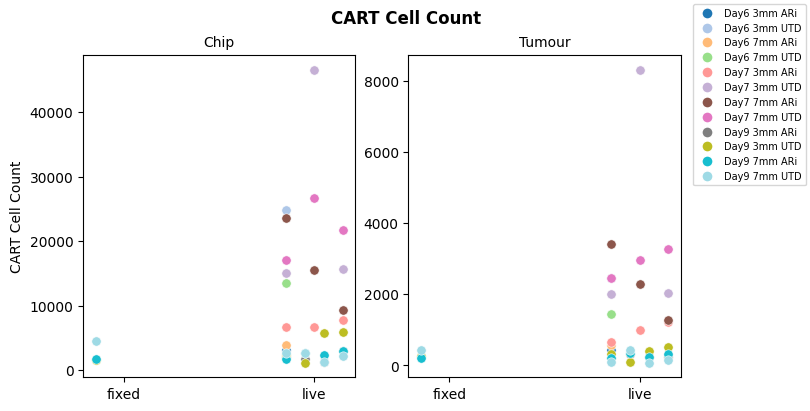

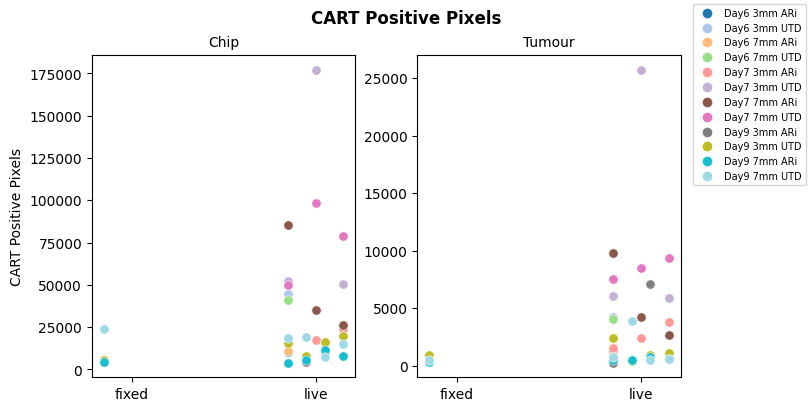

In [93]:
# ══════════════════════════════════════════════════════════════════════════════
# Scatter plot — CART cells by fixation (x-axis) coloured by condition + ARi/UTD
# ══════════════════════════════════════════════════════════════════════════════
cart_data = all_results[
    (all_results["cell_type"] == "CART cells") &
    (all_results["region"].isin(["chip", "tumour"])) &
    (all_results["day"] != "unknown")
].copy()

# Build condition label that includes ARi/UTD
cart_data["condition"] = (
    "Day" + cart_data["day"] + " " +
    cart_data["flow"] + " " +
    cart_data["experiment"]
)

# Sort conditions logically: day → flow → experiment
cart_data["sort_key"] = (
    cart_data["day"].astype(int) * 100 +
    cart_data["flow"].map({"3mm": 0, "7mm": 1}) * 10 +
    cart_data["experiment"].map({"ARi": 0, "UTD": 1})
)
cart_data = cart_data.sort_values("sort_key")
condition_order = cart_data["condition"].unique()

fixation_categories = ["fixed", "live"]
plot_regions = ["chip", "tumour"]
metrics = [("cell_count", "CART Cell Count"), ("positive_pixels", "CART Positive Pixels")]

condition_colors = {cond: plt.cm.tab20(i / max(len(condition_order) - 1, 1))
                    for i, cond in enumerate(condition_order)}

for metric, ylabel in metrics:
    fig, axes = plt.subplots(1, len(plot_regions), figsize=(8, 4),
                             sharey=False, constrained_layout=True)
    fig.suptitle(ylabel, fontsize=12, fontweight="bold")

    for ax, region in zip(axes, plot_regions):
        region_data = cart_data[cart_data["region"] == region]

        for fixation_index, fixation in enumerate(fixation_categories):
            fixation_data = region_data[region_data["fixation"] == fixation]
            for condition in condition_order:
                condition_mask = fixation_data["condition"] == condition
                values = fixation_data.loc[condition_mask, metric].values
                jitter = np.linspace(-0.15, 0.15, max(len(values), 1))
                for jitter_offset, value in zip(jitter, values):
                    ax.scatter(fixation_index + jitter_offset, value,
                               color=condition_colors[condition], s=45,
                               edgecolor="white", linewidth=0.4, zorder=3)

        ax.set_xticks(range(len(fixation_categories)))
        ax.set_xticklabels(fixation_categories, fontsize=10)
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    legend_handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=condition_colors[condition], markersize=8,
               label=condition)
        for condition in condition_order
    ]
    fig.legend(handles=legend_handles, loc="outside right upper", fontsize=7, ncol=1)
    plt.savefig(f"CART_{metric}_by_condition.png", dpi=150, bbox_inches="tight")
    plt.show()